# SmartCloset AI PoC 評価 Notebook 完全版

このNotebookでは、単一ファッションアイテム画像に対して以下を評価する。

1. YOLOv8-segによる対象物の切り出し
2. マスク画像・背景透過PNG・YOLO可視化画像の保存
3. Geminiによる属性抽出
4. 人手評価によるPoC成功率の算出

今回の主目的は **YOLOの分類精度ではなく、クローゼット登録に使える切り出しと属性抽出ができるか** を確認することである。

評価対象の属性は以下。

- category
- color_primary
- pattern
- material

`silhouette` はGeminiから取得するが、今回の主要な成功率評価からは外す。


## 0. 評価基準

### YOLOのセグメンテーション評価

今回は対象物を切り出し、マスクを生成することが重要である。そのため、YOLOの予測クラスが正解クラスと一致しているかどうかは主評価にしない。

| 評価 | 基準 |
|---|---|
| ○ | 対象物を見つけ、きちんと切り出している |
| △ | 一部欠損、または背景混入がある |
| × | 検出失敗、または登録に使えない |

### LLMによる属性認識評価

| 項目 | ○ | △ | × |
|---|---|---|---|
| category | 正しい分類 | 近い分類・上位概念 | 明確に違う分類 |
| color_primary | 主色が一致 | 近い色・明暗差程度 | 違う色 |
| pattern | 柄が一致 | 近い柄・判断が微妙 | 違う柄 |
| material | 素材感が一致 | 近い素材・判断が微妙 | 違う素材 |

### pattern の候補

pattern は **柄・デザイン** を表す。

- 無地
- ストライプ
- ボーダー
- チェック
- ドット
- 花柄
- ロゴ
- プリント
- カモフラ
- その他

### material の候補

material は **素材・質感** を表す。

- コットン
- デニム
- ニット
- レザー
- ナイロン
- フリース
- ウール
- スウェット
- ファー
- ボア
- 金属
- 樹脂
- その他

例：

|アイテム|pattern|material|
|---|---|---|
|黒いウィンドブレーカー|無地|ナイロン|
|デニムパンツ|無地|デニム|
|ニット帽|無地|ニット|
|レザーバッグ|無地|レザー|
|ロゴTシャツ|ロゴ|コットン|

### 最終登録判定

| 評価 | 基準 |
|---|---|
| ○ | YOLO切り出し○、category○、color_primary○、pattern○、material○ |
| △ | YOLO△、または属性が一部△ |
| × | YOLO×、または登録不可レベルの誤り |

最終的に以下を算出する。

- YOLO成功率
- LLMのcategory成功率
- LLMのcolor_primary成功率
- LLMのpattern成功率
- LLMのmaterial成功率
- 最終登録成功率
- クラス別成功率


## 1. ライブラリ読み込み

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from dotenv import load_dotenv
from datetime import datetime
import base64
from openai import OpenAI

pd.set_option("display.max_columns", None)

## 2. パス・クラス設定

Notebookは `ai_prototype/PoC/` で実行する想定。構成は以下。

```text
ai_prototype/
└── PoC/
    ├── smartcloset_poc.ipynb
    └── test_images/
        ├── bag/
        ├── bottoms/
        ├── dress/
        ├── glasses/
        ├── hat/
        ├── outer/
        ├── shoes/
        ├── tops/
        └── watch/
```

In [2]:
BASE_DIR = Path(".")
TEST_IMAGE_DIR = BASE_DIR / "test_images"

# PoCフォルダから見たモデルパス
MODEL_PATH = Path("../../models/fashionpedia_9class_with_data_augmentation.pt")

CLASS_NAMES = [
    "outer",
    "tops",
    "bottoms",
    "dress",
    "shoes",
    "bag",
    "hat",
    "watch",
    "glasses",
]

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

OUTPUT_DIR = BASE_DIR / "output"
MASK_DIR = OUTPUT_DIR / "masks"
TRANSPARENT_DIR = OUTPUT_DIR / "transparent"
ANNOTATED_DIR = OUTPUT_DIR / "annotated"

for d in [OUTPUT_DIR, MASK_DIR, TRANSPARENT_DIR, ANNOTATED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_CSV_PATH = OUTPUT_DIR / "poc_results.csv"
EVAL_CSV_PATH = OUTPUT_DIR / "poc_manual_eval.csv"
SUMMARY_CSV_PATH = OUTPUT_DIR / "poc_summary.csv"
CLASS_SUMMARY_CSV_PATH = OUTPUT_DIR / "poc_class_summary.csv"

CONF_THRES = 0.25

print("TEST_IMAGE_DIR:", TEST_IMAGE_DIR.resolve())
print("MODEL_PATH:", MODEL_PATH.resolve())
print("model exists:", MODEL_PATH.exists())

TEST_IMAGE_DIR: /users/tw/takahashi/SmartCloset_AI/ai_prototype/Poc/test_images
MODEL_PATH: /users/tw/takahashi/SmartCloset_AI/models/fashionpedia_9class_with_data_augmentation.pt
model exists: True


## 3. モデル読み込み

In [3]:
model_yolo = YOLO(MODEL_PATH)
print("YOLO model loaded")

YOLO model loaded


## 4. PoC画像一覧を取得

In [4]:
image_records = []

for true_class in CLASS_NAMES:
    class_dir = TEST_IMAGE_DIR / true_class

    if not class_dir.exists():
        print(f"Warning: {class_dir} が存在しません")
        continue

    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() in IMAGE_EXTS:
            image_records.append({
                "image_path": str(img_path),
                "true_class": true_class,
                "file_name": img_path.name,
            })

df_images = pd.DataFrame(image_records)

print(f"画像枚数: {len(df_images)}")
df_images.head()

画像枚数: 251


,image_path,true_class,file_name
0,test_images/outer/outer001.jpeg,outer,outer001.jpeg
1,test_images/outer/outer002.jpeg,outer,outer002.jpeg
2,test_images/outer/outer003.jpeg,outer,outer003.jpeg
3,test_images/outer/outer004.jpeg,outer,outer004.jpeg
4,test_images/outer/outer005.jpeg,outer,outer005.jpeg


## 5. YOLOセグメンテーション関数

1画像1アイテムを前提にする。ただし、靴のように左右で複数インスタンスとして検出される場合があるため、代表クラスと同じクラスのマスクを合成する。

これにより、靴が片方だけ背景透過される問題を避ける。

In [5]:
def segment_item(image_path, conf=CONF_THRES):
    """
    画像から対象物をセグメンテーションし、マスク・背景透過画像・メタ情報を返す。

    方針:
    - 最も信頼度が高い検出を代表検出とする
    - 代表検出と同じクラスのインスタンスはすべて合成する
    - YOLOの予測クラスは参考情報として保存する
    """
    image_path = Path(image_path)

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None, None, None, None, "image_read_error"

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = model_yolo.predict(
        source=str(image_path),
        conf=conf,
        save=False,
        verbose=False,
    )

    result = results[0]

    if result.masks is None or len(result.masks.data) == 0:
        return None, None, result, None, "no_mask"

    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes

    confs = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)

    best_idx = int(np.argmax(confs))
    pred_class_id = int(cls_ids[best_idx])
    pred_class = CLASS_NAMES[pred_class_id]
    confidence = float(confs[best_idx])

    target_indices = np.where(cls_ids == pred_class_id)[0]

    combined_mask = np.zeros_like(masks[0], dtype=np.float32)
    for idx in target_indices:
        combined_mask = np.maximum(combined_mask, masks[idx])

    mask = (combined_mask * 255).astype(np.uint8)
    mask = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))

    rgba = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2RGBA)
    rgba[:, :, 3] = mask

    info = {
        "pred_class": pred_class,
        "confidence": confidence,
        "num_instances": int(len(target_indices)),
        "all_pred_classes": [CLASS_NAMES[int(c)] for c in cls_ids],
        "all_confidences": [float(c) for c in confs],
    }

    return rgba, mask, result, info, "success"

## 6. 1枚だけ推論確認

sample_path: test_images/outer/outer001.jpeg
status: success
yolo_info: {'pred_class': 'tops', 'confidence': 0.64984130859375, 'num_instances': 1, 'all_pred_classes': ['tops', 'outer'], 'all_confidences': [0.64984130859375, 0.4381430447101593]}


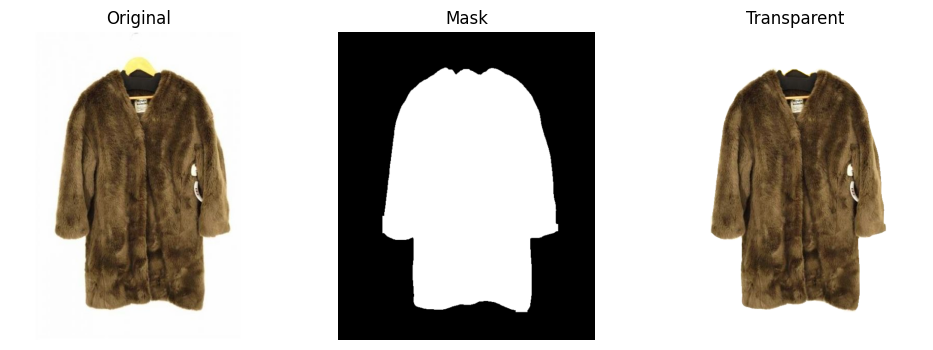

In [6]:
sample_path = df_images.iloc[0]["image_path"]
rgba, mask, yolo_result, yolo_info, status = segment_item(sample_path)

print("sample_path:", sample_path)
print("status:", status)
print("yolo_info:", yolo_info)

original_img = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
if mask is not None:
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
else:
    plt.text(0.5, 0.5, "No mask", ha="center", va="center")
plt.axis("off")

plt.subplot(1, 3, 3)
if rgba is not None:
    plt.imshow(rgba)
    plt.title("Transparent")
else:
    plt.text(0.5, 0.5, "No transparent", ha="center", va="center")
plt.axis("off")

plt.show()

## 7. OPENAI_API_KEY設定

`.env` に以下を設定しておく。

```text
OPENAI_API_KEY=xxxxxxxx
```

APIキーがない場合、このセル以降のOEPNAI処理は実行できない。YOLO評価だけならここをスキップしてよい。

In [7]:
from openai import OpenAI

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY:
    client = OpenAI(api_key=OPENAI_API_KEY)
else:
    client = None

## 8. OPENAI属性抽出関数

In [8]:
def parse_json_safely(text):
    """OpenAIの出力をJSONとして安全に読み込む。"""
    try:
        data = json.loads(text)
    except Exception:
        cleaned = text.strip()
        cleaned = cleaned.replace("```json", "").replace("```", "").strip()

        try:
            data = json.loads(cleaned)
        except Exception:
            return {
                "category": None,
                "color_primary": None,
                "color_secondary": None,
                "pattern": None,
                "material": None,
                "silhouette": None,
                "raw_response": text,
                "openai_error": "json_parse_error",
            }

    default_keys = [
        "category",
        "color_primary",
        "color_secondary",
        "pattern",
        "material",
        "silhouette",
    ]

    for key in default_keys:
        if key not in data:
            data[key] = None

    return data

def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")
        
def extract_metadata_with_openai(image_path):
    """背景透過画像をOpenAI APIに渡し、属性JSONを得る。"""

    if client is None:
        return {
            "category": None,
            "color_primary": None,
            "color_secondary": None,
            "pattern": None,
            "material": None,
            "silhouette": None,
            "openai_error": "OPENAI_API_KEY_not_found",
        }

    prompt = """
このファッションアイテム画像を解析してください。

以下のJSON形式のみで返してください。

{
  "category": "",
  "color_primary": "",
  "color_secondary": "",
  "pattern": "",
  "material": "",
  "silhouette": ""
}

ルール:
- category は outer, tops, bottoms, dress, shoes, bag, hat, watch, glasses のいずれかに近いカテゴリで答える
- color_primary は主色を答える
- color_secondary は副色がなければ null
- pattern は柄・デザインを答える
- material は素材・質感を答える
- silhouette は形状・サイズ感・デザイン特徴を簡潔に答える
- 日本語で出力する
- JSON以外を出力しない
- 空欄は禁止
- 判断が難しい場合は「その他」を選ぶ

pattern は以下から最も近いものを必ず1つ選ぶ:

- 無地
- ストライプ
- ボーダー
- チェック
- ドット
- 花柄
- ロゴ
- プリント
- カモフラ
- その他

material は以下から最も近いものを必ず1つ選ぶ:

- コットン
- デニム
- ニット
- レザー
- ナイロン
- フリース
- ウール
- スウェット
- ファー
- ボア
- 金属
- 樹脂
- その他

注意:

- デニム、ニット、レザー、ナイロンなどは pattern ではなく material に入れる
- 無地のウィンドブレーカーは pattern=無地, material=ナイロン
- デニムパンツは pattern=無地, material=デニム
- ニット帽は pattern=無地, material=ニット
- ファーコートは pattern=無地, material=ファー
- ボアジャケットは pattern=無地, material=ボア
- 時計や眼鏡など素材判定が難しい場合は見た目から最も近い material を選ぶ
- 分からない場合は material="その他" とする
- material を空欄や null にしない
- pattern を空欄や null にしない

例:

{
  "category": "outer",
  "color_primary": "ブラウン",
  "color_secondary": null,
  "pattern": "無地",
  "material": "ファー",
  "silhouette": "ロングコート"
}
"""

    base64_image = image_to_base64(image_path)

    response = client.chat.completions.create(
        model="gpt-5.4-nano",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}"
                        },
                    },
                ],
            }
        ],
        response_format={"type": "json_object"},
    )

    text = response.choices[0].message.content
    return parse_json_safely(text)

## 9. 全画像に対して YOLO → マスク保存 → 背景透過保存 → OPENAI

時間がかかるため、まず `RUN_OPENAI = False` でYOLO処理だけ実行してもよい。OEPNAIまで一括実行する場合は `True` にする。

In [9]:
RUN_OPENAI = True  # OpenAI APIを実行しない場合は False

results = []

for i, row in df_images.iterrows():
    image_path = Path(row["image_path"])
    true_class = row["true_class"]

    print(f"[{i+1}/{len(df_images)}] {image_path}")

    rgba, mask, yolo_result, yolo_info, status = segment_item(image_path)

    mask_path = None
    transparent_path = None
    annotated_path = None
    metadata = {}

    if status == "success":
        stem = f"{true_class}_{image_path.stem}"

        mask_path = MASK_DIR / f"{stem}_mask.png"
        transparent_path = TRANSPARENT_DIR / f"{stem}_transparent.png"
        annotated_path = ANNOTATED_DIR / f"{stem}_annotated.png"

        Image.fromarray(mask).save(mask_path)
        Image.fromarray(rgba).save(transparent_path)

        annotated = yolo_result.plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        Image.fromarray(annotated_rgb).save(annotated_path)

        if RUN_OPENAI:
            try:
                metadata = extract_metadata_with_openai(transparent_path)
            except Exception as e:
                metadata = {"openai_error": str(e)}

    results.append({
        "image_path": str(image_path),
        "file_name": image_path.name,
        "true_class": true_class,
        "yolo_status": status,
        "yolo_pred_class": yolo_info["pred_class"] if yolo_info else None,
        "yolo_confidence": yolo_info["confidence"] if yolo_info else None,
        "num_instances": yolo_info["num_instances"] if yolo_info else None,
        "all_pred_classes": json.dumps(yolo_info["all_pred_classes"], ensure_ascii=False) if yolo_info else None,
        "all_confidences": json.dumps(yolo_info["all_confidences"], ensure_ascii=False) if yolo_info else None,
        "mask_path": str(mask_path) if mask_path else None,
        "transparent_path": str(transparent_path) if transparent_path else None,
        "annotated_path": str(annotated_path) if annotated_path else None,

        "category": metadata.get("category"),
        "color_primary": metadata.get("color_primary"),
        "color_secondary": metadata.get("color_secondary"),
        "pattern": metadata.get("pattern"),
        "material": metadata.get("material"),
        "silhouette": metadata.get("silhouette"),

        "openai_error": metadata.get("openai_error"),
        "raw_response": metadata.get("raw_response"),
    })


df_results = pd.DataFrame(results)
df_results.to_csv(RAW_CSV_PATH, index=False, encoding="utf-8-sig")

print("saved:", RAW_CSV_PATH)
df_results.head()

[1/251] test_images/outer/outer001.jpeg
[2/251] test_images/outer/outer002.jpeg
[3/251] test_images/outer/outer003.jpeg
[4/251] test_images/outer/outer004.jpeg
[5/251] test_images/outer/outer005.jpeg
[6/251] test_images/outer/outer006.jpeg
[7/251] test_images/outer/outer007.jpeg
[8/251] test_images/outer/outer008.jpeg
[9/251] test_images/outer/outer009.jpeg
[10/251] test_images/outer/outer010.jpeg
[11/251] test_images/outer/outer011.jpeg
[12/251] test_images/outer/outer012.jpeg
[13/251] test_images/outer/outer013.jpeg
[14/251] test_images/outer/outer014.jpeg
[15/251] test_images/outer/outer015.jpeg
[16/251] test_images/outer/outer016.jpeg
[17/251] test_images/outer/outer017.jpeg
[18/251] test_images/outer/outer018.jpeg
[19/251] test_images/outer/outer019.jpeg
[20/251] test_images/outer/outer020.jpeg
[21/251] test_images/outer/outer021.jpeg
[22/251] test_images/outer/outer022.jpeg
[23/251] test_images/outer/outer023.jpeg
[24/251] test_images/outer/outer024.jpeg
[25/251] test_images/oute

,image_path,file_name,true_class,yolo_status,yolo_pred_class,yolo_confidence,num_instances,all_pred_classes,all_confidences,mask_path,transparent_path,annotated_path,category,color_primary,color_secondary,pattern,material,silhouette,openai_error,raw_response
0,test_images/outer/outer001.jpeg,outer001.jpeg,outer,success,tops,0.649841,1.0,"[""tops"", ""outer""]","[0.64984130859375, 0.4381430447101593]",output/masks/outer_outer001_mask.png,output/transparent/outer_outer001_transparent.png,output/annotated/outer_outer001_annotated.png,outer,カーキ,NaN,無地,ファー,ミドル丈のボタンフロントコート風アウター,None,None
1,test_images/outer/outer002.jpeg,outer002.jpeg,outer,success,outer,0.933415,1.0,"[""outer""]",[0.9334152936935425],output/masks/outer_outer002_mask.png,output/transparent/outer_outer002_transparent.png,output/annotated/outer_outer002_annotated.png,outer,ベージュ,ブラウン,無地,ナイロン,ミドル丈のダウン/中綿コート型、フード付きでファー付き、Aライン寄りのボリュームシルエット,None,None
2,test_images/outer/outer003.jpeg,outer003.jpeg,outer,success,outer,0.894240,1.0,"[""outer""]",[0.8942398428916931],output/masks/outer_outer003_mask.png,output/transparent/outer_outer003_transparent.png,output/annotated/outer_outer003_annotated.png,outer,ブラウン,NaN,無地,ボア,ボリューム感のあるショート丈のダブルブレストジャケット,None,None
3,test_images/outer/outer004.jpeg,outer004.jpeg,outer,success,outer,0.881838,1.0,"[""outer""]",[0.8818376064300537],output/masks/outer_outer004_mask.png,output/transparent/outer_outer004_transparent.png,output/annotated/outer_outer004_annotated.png,outer,ブルーグレー,NaN,無地,ファー,ショート丈のライダース風（ジップフロント、ベルト付き）,None,None
4,test_images/outer/outer005.jpeg,outer005.jpeg,outer,success,outer,0.908734,1.0,"[""outer""]",[0.908733606338501],output/masks/outer_outer005_mask.png,output/transparent/outer_outer005_transparent.png,output/annotated/outer_outer005_annotated.png,outer,ブラック,ゴールド,無地,レザー,ボクシーなショート丈ジャケット（オーバーサイズ寄り）,None,None


## 10. 簡易評価

ここでは自動的に分かる範囲のみ確認する。`yolo_class_match_rate` は参考値であり、PoCの主指標ではない。

In [3]:
df_results = pd.read_csv(RAW_CSV_PATH)

df_results["yolo_detected"] = df_results["yolo_status"] == "success"
df_results["yolo_class_match"] = df_results["true_class"] == df_results["yolo_pred_class"]

simple_summary = {
    "total_images": len(df_results),
    "yolo_detected_rate": df_results["yolo_detected"].mean(),
    "yolo_class_match_rate_reference": df_results["yolo_class_match"].mean(),
}

simple_summary

{'total_images': 251,
 'yolo_detected_rate': np.float64(0.9960159362549801),
 'yolo_class_match_rate_reference': np.float64(0.8804780876494024)}

## 11. 手動評価CSVを作成

ここからがPoC評価の本体。各画像について以下を人手で評価する。

- `yolo_seg_score`: YOLO切り出し評価
- `category_score`: LLMカテゴリ評価
- `color_primary_score`: LLM主色評価
- `pattern_score`: LLM柄評価
- `material_score`: LLM素材評価
- `final_result`: 最終登録判定
- `comment`: 失敗理由や補足


In [4]:
df_eval = df_results.copy()

eval_cols = [
    "yolo_seg_score",
    "category_score",
    "color_primary_score",
    "pattern_score",
    "material_score",
    "final_result",
    "comment",
]

for col in eval_cols:
    if col not in df_eval.columns:
        df_eval[col] = ""

# 既に評価CSVがある場合は、そちらを優先して読み込む
if EVAL_CSV_PATH.exists():
    print("既存の評価CSVを読み込みます:", EVAL_CSV_PATH)
    df_existing = pd.read_csv(EVAL_CSV_PATH).fillna("")

    # 既存CSVに新しい列がない場合は追加する
    for col in df_results.columns:
        if col not in df_existing.columns:
            df_existing[col] = df_results[col]

    for col in eval_cols:
        if col not in df_existing.columns:
            df_existing[col] = ""

    df_eval = df_existing
else:
    df_eval.to_csv(EVAL_CSV_PATH, index=False, encoding="utf-8-sig")
    print("新規評価CSVを作成しました:", EVAL_CSV_PATH)

# material / silhouette が古いCSVに存在しない場合の保険
for col in ["material", "silhouette"]:
    if col not in df_eval.columns:
        df_eval[col] = ""

df_eval.to_csv(EVAL_CSV_PATH, index=False, encoding="utf-8-sig")
df_eval.head()

既存の評価CSVを読み込みます: output/poc_manual_eval.csv


,image_path,file_name,true_class,yolo_status,yolo_pred_class,yolo_confidence,num_instances,all_pred_classes,all_confidences,mask_path,transparent_path,annotated_path,category,color_primary,color_secondary,pattern,material,silhouette,openai_error,raw_response,yolo_detected,yolo_class_match,yolo_seg_score,category_score,color_primary_score,pattern_score,material_score,final_result,comment
0,test_images/outer/outer001.jpeg,outer001.jpeg,outer,success,tops,0.649841,1.0,"[""tops"", ""outer""]","[0.64984130859375, 0.4381430447101593]",output/masks/outer_outer001_mask.png,output/transparent/outer_outer001_transparent.png,output/annotated/outer_outer001_annotated.png,outer,カーキ,,無地,ファー,ミドル丈のボタンフロントコート風アウター,,,True,False,○,○,○,○,○,○,問題なく登録可能
1,test_images/outer/outer002.jpeg,outer002.jpeg,outer,success,outer,0.933415,1.0,"[""outer""]",[0.9334152936935425],output/masks/outer_outer002_mask.png,output/transparent/outer_outer002_transparent.png,output/annotated/outer_outer002_annotated.png,outer,ベージュ,ブラウン,無地,ナイロン,ミドル丈のダウン/中綿コート型、フード付きでファー付き、Aライン寄りのボリュームシルエット,,,True,True,○,○,○,○,○,○,問題なく登録可能
2,test_images/outer/outer003.jpeg,outer003.jpeg,outer,success,outer,0.89424,1.0,"[""outer""]",[0.8942398428916931],output/masks/outer_outer003_mask.png,output/transparent/outer_outer003_transparent.png,output/annotated/outer_outer003_annotated.png,outer,ブラウン,,無地,ボア,ボリューム感のあるショート丈のダブルブレストジャケット,,,True,True,○,○,○,○,○,○,問題なく登録可能
3,test_images/outer/outer004.jpeg,outer004.jpeg,outer,success,outer,0.881838,1.0,"[""outer""]",[0.8818376064300537],output/masks/outer_outer004_mask.png,output/transparent/outer_outer004_transparent.png,output/annotated/outer_outer004_annotated.png,outer,ブルーグレー,,無地,ファー,ショート丈のライダース風（ジップフロント、ベルト付き）,,,True,True,○,○,○,○,○,○,問題なく登録可能
4,test_images/outer/outer005.jpeg,outer005.jpeg,outer,success,outer,0.908734,1.0,"[""outer""]",[0.908733606338501],output/masks/outer_outer005_mask.png,output/transparent/outer_outer005_transparent.png,output/annotated/outer_outer005_annotated.png,outer,ブラック,ゴールド,無地,レザー,ボクシーなショート丈ジャケット（オーバーサイズ寄り）,,,True,True,△,○,○,○,○,△,問題なく登録可能


## 12. 人手評価フロー

ここからは、`show_next_unrated()` → 画像を確認 → `set_eval(...)` の流れで1枚ずつ評価する。

表示される内容は以下。

- 元画像
- マスク画像
- 背景透過画像
- YOLO可視化画像
- YOLOの検出情報
- Geminiの属性抽出結果
  - category
  - color_primary
  - color_secondary
  - pattern
  - material
  - silhouette

基本的には `show_eval_sample(idx)` を直接使うより、`show_next_unrated()` を使う。特定の画像を見直したいときだけ `show_eval_sample(idx)` を使う。


In [5]:
def _open_image_or_none(path):
    """画像パスが存在すればPIL Imageとして開く。存在しなければNoneを返す。"""
    if path is None or path == "" or pd.isna(path):
        return None

    p = Path(path)
    if not p.exists():
        return None

    return Image.open(p)


def show_eval_sample(idx):
    """
    指定したindexの評価用情報を表示する。

    使いどころ:
    - 特定の画像を見直したいとき
    - 評価済みサンプルを再確認したいとき

    通常の252枚評価では show_next_unrated() を使う。
    """
    row = df_eval.loc[idx]

    original_img = _open_image_or_none(row.get("image_path"))
    mask_img = _open_image_or_none(row.get("mask_path"))
    transparent_img = _open_image_or_none(row.get("transparent_path"))
    annotated_img = _open_image_or_none(row.get("annotated_path"))

    print("=" * 60)
    print(f"index              : {idx}")
    print(f"file_name          : {row.get('file_name', '')}")
    print(f"true_class         : {row.get('true_class', '')}")
    print(f"yolo_status        : {row.get('yolo_status', '')}")
    print(f"yolo_pred_class    : {row.get('yolo_pred_class', '')}")
    print(f"yolo_confidence    : {row.get('yolo_confidence', '')}")
    print(f"num_instances      : {row.get('num_instances', '')}")
    print("-" * 60)
    print("Gemini result")
    print(f"category           : {row.get('category', '')}")
    print(f"color_primary      : {row.get('color_primary', '')}")
    print(f"color_secondary    : {row.get('color_secondary', '')}")
    print(f"pattern            : {row.get('pattern', '')}")
    print(f"material           : {row.get('material', '')}")
    print(f"silhouette         : {row.get('silhouette', '')}")
    print("-" * 60)
    print("Current manual scores")
    print(f"yolo_seg_score     : {row.get('yolo_seg_score', '')}")
    print(f"category_score     : {row.get('category_score', '')}")
    print(f"color_primary_score: {row.get('color_primary_score', '')}")
    print(f"pattern_score      : {row.get('pattern_score', '')}")
    print(f"material_score     : {row.get('material_score', '')}")
    print(f"final_result       : {row.get('final_result', '')}")
    print(f"comment            : {row.get('comment', '')}")
    print("=" * 60)

    images = [
        ("Original", original_img),
        ("Mask", mask_img),
        ("Transparent", transparent_img),
        ("YOLO Annotated", annotated_img),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    for ax, (title, img) in zip(axes, images):
        ax.set_title(title)
        ax.axis("off")

        if img is None:
            ax.text(0.5, 0.5, "No image", ha="center", va="center")
        else:
            if title == "Mask":
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(img)

    plt.tight_layout()
    plt.show()

    return idx


def show_next_unrated():
    """
    まだfinal_resultが空欄のサンプルを1枚表示する。

    252枚評価では基本的にこの関数を使う。

    使い方:
    idx = show_next_unrated()
    """
    target = df_eval[df_eval["final_result"].fillna("") == ""]

    if len(target) == 0:
        print("すべて評価済みです。")
        return None

    idx = int(target.index[0])
    show_eval_sample(idx)
    print(f"次に評価する index: {idx}")
    return idx

## 13. 評価入力関数

評価は `○`、`△`、`×` の3段階で入力する。

`final_result` を省略すると、以下のルールで自動判定する。

- どれか1つでも `×` → `×`
- すべて `○` → `○`
- それ以外 → `△`

つまり、基本的には `final_result=None` のままでよい。最終判定だけ手動で上書きしたい場合に `final_result="○"` などを指定する。

今回の最終判定には `material_score` も含める。


In [6]:
VALID_SCORES = {"○", "△", "×", ""}


def judge_final_result(
    yolo_seg_score,
    category_score,
    color_primary_score,
    pattern_score,
    material_score,
):
    """
    SmartCloset PoCの最終登録判定ルール。

    ○: YOLO切り出し○、category○、color_primary○、pattern○、material○
    △: YOLO△、または属性が一部△
    ×: YOLO×、または属性に×があり登録不可
    """
    scores = [
        yolo_seg_score,
        category_score,
        color_primary_score,
        pattern_score,
        material_score,
    ]

    if "×" in scores:
        return "×"

    if all(s == "○" for s in scores):
        return "○"

    return "△"


def set_eval(
    idx,
    yolo_seg_score,
    category_score,
    color_primary_score,
    pattern_score,
    material_score,
    final_result=None,
    comment="",
):
    """
    1画像ぶんの評価を入力してCSVへ保存する。

    例:
    set_eval(
        idx,
        yolo_seg_score="△",
        category_score="○",
        color_primary_score="○",
        pattern_score="○",
        material_score="△",
        comment="時計本体は切り出せているがベルト部分に欠損あり"
    )
    """
    scores = [
        yolo_seg_score,
        category_score,
        color_primary_score,
        pattern_score,
        material_score,
    ]

    for s in scores:
        if s not in VALID_SCORES:
            raise ValueError("評価は '○', '△', '×' のいずれかで入力してください。")

    if final_result is None:
        final_result = judge_final_result(
            yolo_seg_score,
            category_score,
            color_primary_score,
            pattern_score,
            material_score,
        )

    if final_result not in VALID_SCORES:
        raise ValueError("final_resultは '○', '△', '×' のいずれかで入力してください。")

    df_eval.loc[idx, "yolo_seg_score"] = yolo_seg_score
    df_eval.loc[idx, "category_score"] = category_score
    df_eval.loc[idx, "color_primary_score"] = color_primary_score
    df_eval.loc[idx, "pattern_score"] = pattern_score
    df_eval.loc[idx, "material_score"] = material_score
    df_eval.loc[idx, "final_result"] = final_result
    df_eval.loc[idx, "comment"] = comment

    df_eval.to_csv(EVAL_CSV_PATH, index=False, encoding="utf-8-sig")

    print(f"saved index {idx}")
    print(f"final_result: {final_result}")

    return df_eval.loc[idx]

## 14. 手動評価

- 未評価の画像を評価する

1. `idx = show_next_unrated()` を実行する
2. 元画像、マスク、背景透過画像、Gemini結果を見る
3. `set_eval(...)` で評価を保存する
4. また `idx = show_next_unrated()` を実行する

評価例を下に残している。コメントアウトを外して使う。

In [493]:
# 1. 未評価画像を表示
idx = show_next_unrated()

#2. 表示された画像を見て評価を保存
# set_eval(
#     idx,
#     yolo_seg_score="△",
#     category_score="○",
#     color_primary_score="○",
#     pattern_score="○",
#     material_score="○",
#     comment="多少欠けてはいるが、基本的に問題なく登録可能"
# )

# 例: 時計のベルトが欠損している場合
# set_eval(
#     idx,
#     yolo_seg_score="◯",
#     category_score="○",
#     color_primary_score="○",
#     pattern_score="○",
#     material_score="△",
#     comment="時計本体は切り出せているがベルト部分に欠損あり"
# )

# 例: 黒いウィンドブレーカーの場合
# pattern は無地、material はナイロンとして評価する
# set_eval(
#     idx,
#     yolo_seg_score="○",
#     category_score="○",
#     color_primary_score="○",
#     pattern_score="○",
#     material_score="○",
#     comment="pattern=無地, material=ナイロンとして妥当"
# )

#素材
#×,○,△

すべて評価済みです。


- 特定のidxの評価を変更する

index              : 187
file_name          : bag020.jpeg
true_class         : bag
yolo_status        : success
yolo_pred_class    : bag
yolo_confidence    : 0.8267133235931396
num_instances      : 1.0
------------------------------------------------------------
Gemini result
category           : bag
color_primary      : ブラック
color_secondary    : ゴールド
pattern            : 無地
material           : レザー
silhouette         : 小ぶりのショルダーバッグ（フラップ付き、丸みのあるボックス型）
------------------------------------------------------------
Current manual scores
yolo_seg_score     : ×
category_score     : ○
color_primary_score: ○
pattern_score      : ○
material_score     : ○
final_result       : ×
comment            : ショルダーの部分が消えてしまったので登録不可


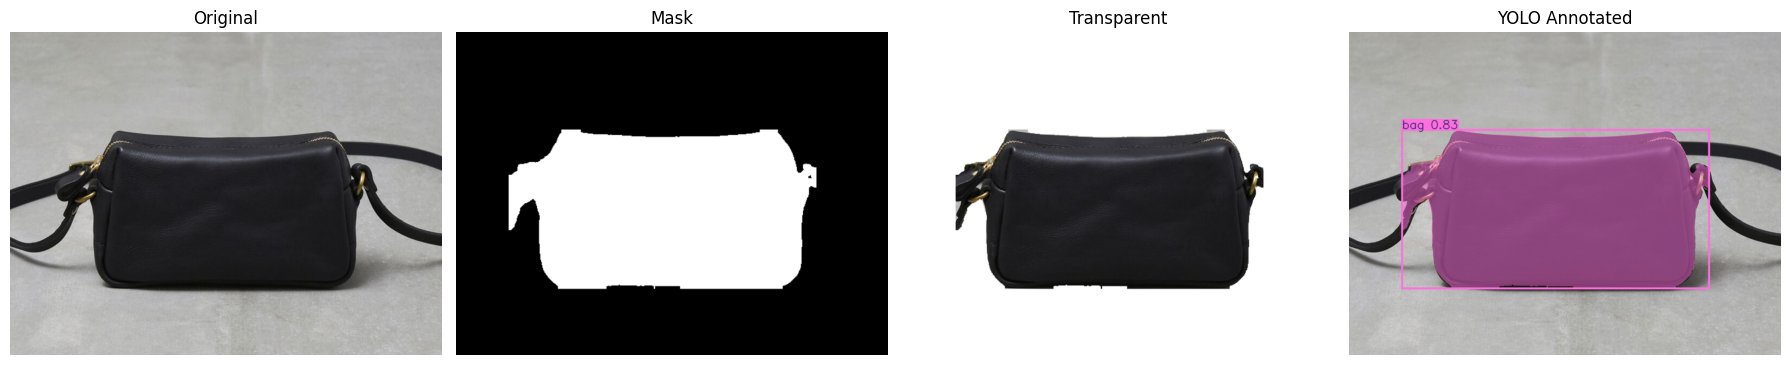

In [536]:
# 1. 特定インデクスを表示
idx=show_eval_sample(187)

#2. 表示された画像を見て評価を保存
# set_eval(
#     idx,
#     yolo_seg_score="○",
#     category_score="○",
#     color_primary_score="○",
#     pattern_score="△",
#     material_score="○",
#     comment="基本的に問題なく登録可能"
# )

## 15. 評価済み件数と○△×の内訳確認

これは途中確認用。最終的な成功率は次のセルで算出する。

In [537]:
def summarize_manual_eval():
    target = df_eval[df_eval["final_result"].fillna("") != ""].copy()

    print(f"評価済み枚数: {len(target)} / {len(df_eval)}")
    print()

    for col in [
        "yolo_seg_score",
        "category_score",
        "color_primary_score",
        "pattern_score",
        "material_score",
        "final_result",
    ]:
        print(f"--- {col} ---")
        print(target[col].value_counts(dropna=False).reindex(["○", "△", "×"], fill_value=0))
        print()

summarize_manual_eval()

評価済み枚数: 251 / 252

--- yolo_seg_score ---
yolo_seg_score
○    201
△     29
×     21
Name: count, dtype: int64

--- category_score ---
category_score
○    244
△      1
×      6
Name: count, dtype: int64

--- color_primary_score ---
color_primary_score
○    248
△      2
×      1
Name: count, dtype: int64

--- pattern_score ---
pattern_score
○    241
△      7
×      3
Name: count, dtype: int64

--- material_score ---
material_score
○    221
△     20
×     10
Name: count, dtype: int64

--- final_result ---
final_result
○    162
△     51
×     38
Name: count, dtype: int64



## 16. 全体成功率の算出

PoCの主要指標。ここでは「○」の割合を成功率とする。

In [538]:
def calc_success_rate(df, col):
    target = df[df[col].fillna("") != ""]
    if len(target) == 0:
        return np.nan
    return float((target[col] == "○").mean())


def calc_acceptable_rate(df, col):
    target = df[df[col].fillna("") != ""]
    if len(target) == 0:
        return np.nan
    return float(target[col].isin(["○", "△"]).mean())


overall_summary = pd.DataFrame([
    {
        "metric": "yolo_seg_success_rate",
        "success_rate": calc_success_rate(df_eval, "yolo_seg_score"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "yolo_seg_score"),
    },
    {
        "metric": "category_success_rate",
        "success_rate": calc_success_rate(df_eval, "category_score"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "category_score"),
    },
    {
        "metric": "color_primary_success_rate",
        "success_rate": calc_success_rate(df_eval, "color_primary_score"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "color_primary_score"),
    },
    {
        "metric": "pattern_success_rate",
        "success_rate": calc_success_rate(df_eval, "pattern_score"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "pattern_score"),
    },
    {
        "metric": "material_success_rate",
        "success_rate": calc_success_rate(df_eval, "material_score"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "material_score"),
    },
    {
        "metric": "final_registration_success_rate",
        "success_rate": calc_success_rate(df_eval, "final_result"),
        "acceptable_rate": calc_acceptable_rate(df_eval, "final_result"),
    },
])

overall_summary.to_csv(SUMMARY_CSV_PATH, index=False, encoding="utf-8-sig")
overall_summary

,metric,success_rate,acceptable_rate
0,yolo_seg_success_rate,0.800797,0.916335
1,category_success_rate,0.972112,0.976096
2,color_primary_success_rate,0.988048,0.996016
3,pattern_success_rate,0.960159,0.988048
4,material_success_rate,0.880478,0.960159
5,final_registration_success_rate,0.645418,0.848606


## 17. クラス別成功率の算出

In [539]:
score_cols = [
    "yolo_seg_score",
    "category_score",
    "color_primary_score",
    "pattern_score",
    "material_score",
    "final_result",
]

class_summary_rows = []

for true_class, g in df_eval.groupby("true_class"):
    row = {
        "true_class": true_class,
        "num_images": len(g),
        "num_evaluated": int((g["final_result"].fillna("") != "").sum()),
    }

    for col in score_cols:
        row[f"{col}_success_rate"] = calc_success_rate(g, col)
        row[f"{col}_acceptable_rate"] = calc_acceptable_rate(g, col)

    class_summary_rows.append(row)

class_summary = pd.DataFrame(class_summary_rows)
class_summary.to_csv(CLASS_SUMMARY_CSV_PATH, index=False, encoding="utf-8-sig")
class_summary

,true_class,num_images,num_evaluated,yolo_seg_score_success_rate,yolo_seg_score_acceptable_rate,category_score_success_rate,category_score_acceptable_rate,color_primary_score_success_rate,color_primary_score_acceptable_rate,pattern_score_success_rate,pattern_score_acceptable_rate,material_score_success_rate,material_score_acceptable_rate,final_result_success_rate,final_result_acceptable_rate
0,bag,21,21,0.666667,0.904762,1.00,1.0,1.00,1.00,0.952381,1.000000,0.952381,0.952381,0.619048,0.857143
1,bottoms,36,36,0.916667,1.000000,1.00,1.0,1.00,1.00,0.972222,0.972222,0.861111,0.944444,0.777778,0.916667
2,dress,20,20,1.000000,1.000000,0.65,0.7,1.00,1.00,0.950000,1.000000,0.850000,1.000000,0.450000,0.700000
3,glasses,20,20,0.850000,0.950000,1.00,1.0,1.00,1.00,0.950000,1.000000,0.800000,0.900000,0.650000,0.850000
4,hat,22,22,0.954545,0.954545,1.00,1.0,1.00,1.00,1.000000,1.000000,0.909091,1.000000,0.863636,0.954545
5,outer,30,30,0.866667,1.000000,1.00,1.0,1.00,1.00,0.933333,0.966667,0.900000,1.000000,0.733333,0.966667
6,shoes,32,32,0.687500,0.906250,1.00,1.0,1.00,1.00,0.906250,0.968750,0.875000,0.937500,0.531250,0.812500
7,tops,50,50,0.860000,0.960000,1.00,1.0,0.94,0.98,0.980000,1.000000,0.900000,1.000000,0.720000,0.940000
8,watch,20,20,0.250000,0.400000,1.00,1.0,1.00,1.00,1.000000,1.000000,0.850000,0.850000,0.250000,0.400000


## 18. 可視化

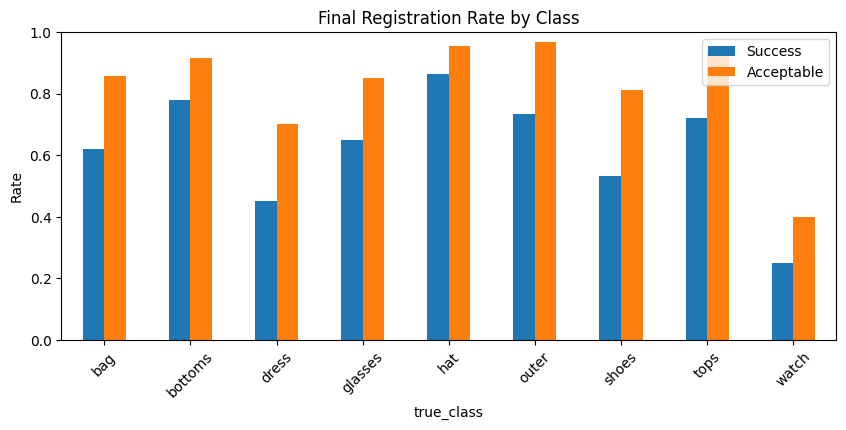

In [540]:
# 評価済みデータのみで可視化
target = df_eval[df_eval["final_result"].fillna("") != ""].copy()

if len(target) > 0:
    plot_df = class_summary.set_index("true_class")

    ax = plot_df[
        [
            "final_result_success_rate",
            "final_result_acceptable_rate",
        ]
    ].plot(kind="bar", figsize=(10, 4))

    ax.set_ylim(0, 1)
    ax.set_ylabel("Rate")
    ax.set_title("Final Registration Rate by Class")
    ax.legend(["Success", "Acceptable"])
    plt.xticks(rotation=45)
    plt.show()

else:
    print("まだ評価済みデータがありません。")

## 19. 失敗事例の確認

`final_result` が `×` または `△` のサンプルを確認する。

In [541]:
pd.set_option("display.max_rows", 100)
def show_problem_samples(n=100):
    problem = df_eval[df_eval["final_result"].isin(["△", "×"])].copy()

    if len(problem) == 0:
        print("問題サンプルはまだありません。")
        return problem

    cols = [
        "true_class",
        "file_name",
        "yolo_pred_class",
        "yolo_seg_score",
        "category",
        "category_score",
        "color_primary",
        "color_primary_score",
        "pattern",
        "pattern_score",
        "material",
        "material_score",
        "final_result",
        "comment",
    ]
    return problem[cols].head(n)

show_problem_samples()

,true_class,file_name,yolo_pred_class,yolo_seg_score,category,category_score,color_primary,color_primary_score,pattern,pattern_score,material,material_score,final_result,comment
4.0,outer,outer005.jpeg,outer,△,outer,○,ブラック,○,無地,○,レザー,○,△,問題なく登録可能
5.0,outer,outer006.jpeg,tops,△,outer,○,グレー,○,チェック,△,その他,○,△,問題なく登録可能
15.0,outer,outer016.jpeg,outer,○,outer,○,カーキ,○,無地,○,ナイロン,△,△,問題なく登録可能
16.0,outer,outer017.jpeg,tops,○,outer,○,アイボリー,○,無地,○,ファー,△,△,問題なく登録可能
19.0,outer,outer020.jpeg,outer,○,outer,○,キャメル,○,無地,○,その他,△,△,問題なく登録可能
20.0,outer,outer021.jpeg,outer,△,outer,○,ホワイト,○,無地,○,ファー,○,△,やや背景が混ざっているが基本問題なく登録可能
21.0,outer,outer022.jpeg,outer,△,outer,○,ブラック,○,無地,○,レザー,○,△,やや背景が混ざっているが基本問題なく登録可能
23.0,outer,outer024.jpeg,outer,○,outer,○,オレンジ,○,チェック,×,ナイロン,○,×,チェック柄ではないので登録不可
30.0,tops,tops001.jpeg,tops,×,tops,○,ネイビー,○,ロゴ,○,スウェット,○,×,背景と同化している部分が途切れているため登録不可
32.0,tops,tops003.jpeg,tops,△,tops,○,オレンジ,○,ロゴ,○,スウェット,○,△,多少途切れているが問題なく登録可能


## 20. PoC結論

```text
SmartCloset AIは、単一ファッションアイテム画像 251 枚に対して、
YOLO-segによる切り出し成功率 80.1%(許容率 91.6%)、
LLMによるカテゴリ認識成功率 97.2%(許容率 97.6%)、
主色認識成功率 99.6%(許容率 99.8%)、
柄認識成功率 96.0%(許容率 98.8%)、
素材認識成功率 88.0%(許容率 96.0%)、
最終登録成功率 64.5%(許容率 84.9%) を達成した。

YOLO-segによる領域抽出とLLMによる属性抽出を組み合わせることで、実利用可能を見据えた衣服登録システムの有効性を確認した。

LLM(gpt-5.4-nano)による属性抽出は高精度であり、SmartCloset AIの属性登録部分はPoC段階で有効性を確認できた。どのクラスにおいても高い精度を示していたが、dressのcategory_scoreが他クラスと比較して突出して低かった。YOLOの学習ではdressクラスにワンピースだけでなく、つなぎやオーバーオールなど上下が一体となった衣服も含めていた。一方、LLMへのプロンプトではdressカテゴリにこれらを含めることを明示していなかったため、つなぎやオーバーオールをtopsやbottomsとして誤分類するケースが見られた。このことから、dressクラスの精度低下はLLMの画像理解能力というよりも、カテゴリ定義およびプロンプト設計に起因するものと考えられる。

一方で、最終登録成功率を下げている主因はYOLOv8-segによる切り出し精度であり、特にwatch・shoes・bagなど小物カテゴリでマスク欠損や背景混入が目立った。watchでは文字盤のみが切り出されベルト部分が欠損するケース、shoesではマスクに欠損が生じるケース、bagではショルダー部分を背景と共に切り出してしまうケースが散見された。これらが成功率が低下の主因となった一方で、許容率を見るとwatchクラスを除きどのクラスも90%を超えている。これらのクラスはfashionpediaのみのファインチューニングでは検出すらされなかったことを鑑みると、追加のファインチューニングは大きな成功であったと言える。

今後は、watchクラスを中心とした小物カテゴリのセグメンテーション精度の改善に加え、LLMプロンプトにおけるカテゴリ定義の明確化を行うことで、最終登録成功率のさらなる向上が期待される。

```
